# Session 2: Descriptive Statistics and Data Structures

In [ ]:
# import liabraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew


In [ ]:
# Create example gene expression data
np.random.seed(42)
gene_data = {
    'Gene': ['BRCA1'] * 100 + ['TP53'] * 100 + ['EGFR'] * 100,
    'Expression': np.concatenate([
        np.random.normal(loc=50, scale=10, size=100),     # BRCA1: normal distribution
        np.random.normal(loc=60, scale=5, size=100),      # TP53: tighter normal
        np.random.exponential(scale=20, size=100) + 30    # EGFR: right-skewed
    ])
}
df = pd.DataFrame(gene_data)
df

,Gene,Expression
0,BRCA1,54.967142
1,BRCA1,48.617357
2,BRCA1,56.476885
3,BRCA1,65.230299
4,BRCA1,47.658466
...,...,...
295,EGFR,47.135649
296,EGFR,39.826014
297,EGFR,50.616543
298,EGFR,42.259119


In [ ]:
df.groupby('Gene')['Expression'].describe()[["mean","std","50%"]]

,mean,std,50%
Gene,,,
BRCA1,48.961535,9.081684,48.730437
EGFR,47.542579,15.098635,44.649447
TP53,60.111523,4.768345,60.420536


In [ ]:
# Calculate descriptive statistics
descriptive_stats = df.groupby('Gene')['Expression'].agg(['mean', 'median', 'std', 'var'])
descriptive_stats

,mean,median,std,var
Gene,,,,
BRCA1,48.961535,48.730437,9.081684,82.476989
EGFR,47.542579,44.649447,15.098635,227.968789
TP53,60.111523,60.420536,4.768345,22.737112


In [ ]:
modes = df.groupby('Gene')['Expression'].agg(lambda x: x.mode().iloc[0])
descriptive_stats['mode'] = modes
descriptive_stats

,mean,median,std,var,mode
Gene,,,,,
BRCA1,48.961535,48.730437,9.081684,82.476989,23.802549
EGFR,47.542579,44.649447,15.098635,227.968789,30.289962
TP53,60.111523,60.420536,4.768345,22.737112,50.406144


In [ ]:
descriptive_stats

,mean,median,std,var,mode
Gene,,,,,
BRCA1,48.961535,48.730437,9.081684,82.476989,23.802549
EGFR,47.542579,44.649447,15.098635,227.968789,30.289962
TP53,60.111523,60.420536,4.768345,22.737112,50.406144


In [ ]:

# Calculate skewness
skewness = df.groupby('Gene')['Expression'].apply(skew).rename('skewness')
descriptive_stats = descriptive_stats.join(skewness)

# Show descriptive stats
descriptive_stats.reset_index()




,Gene,mean,median,std,var,mode,skewness
0,BRCA1,48.961535,48.730437,9.081684,82.476989,23.802549,-0.175268
1,EGFR,47.542579,44.649447,15.098635,227.968789,30.289962,1.386939
2,TP53,60.111523,60.420536,4.768345,22.737112,50.406144,0.381155


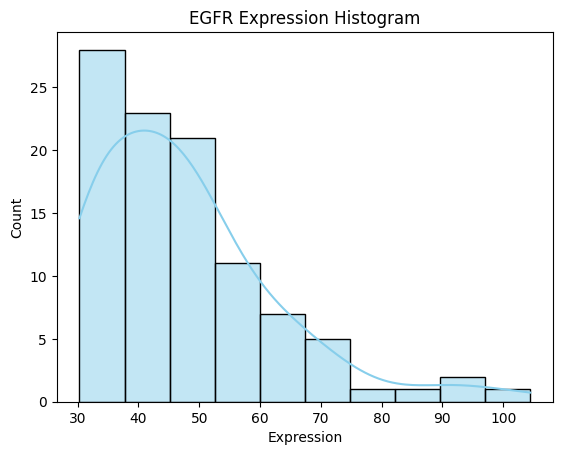

In [ ]:
data = df[df['Gene'] == 'EGFR']['Expression']

# Histogram with KDE
sns.histplot(data, kde=True, color='skyblue')
plt.title(f"EGFR Expression Histogram")
plt.show()

In [ ]:
df['Gene'].unique()

array(['BRCA1', 'TP53', 'EGFR'], dtype=object)

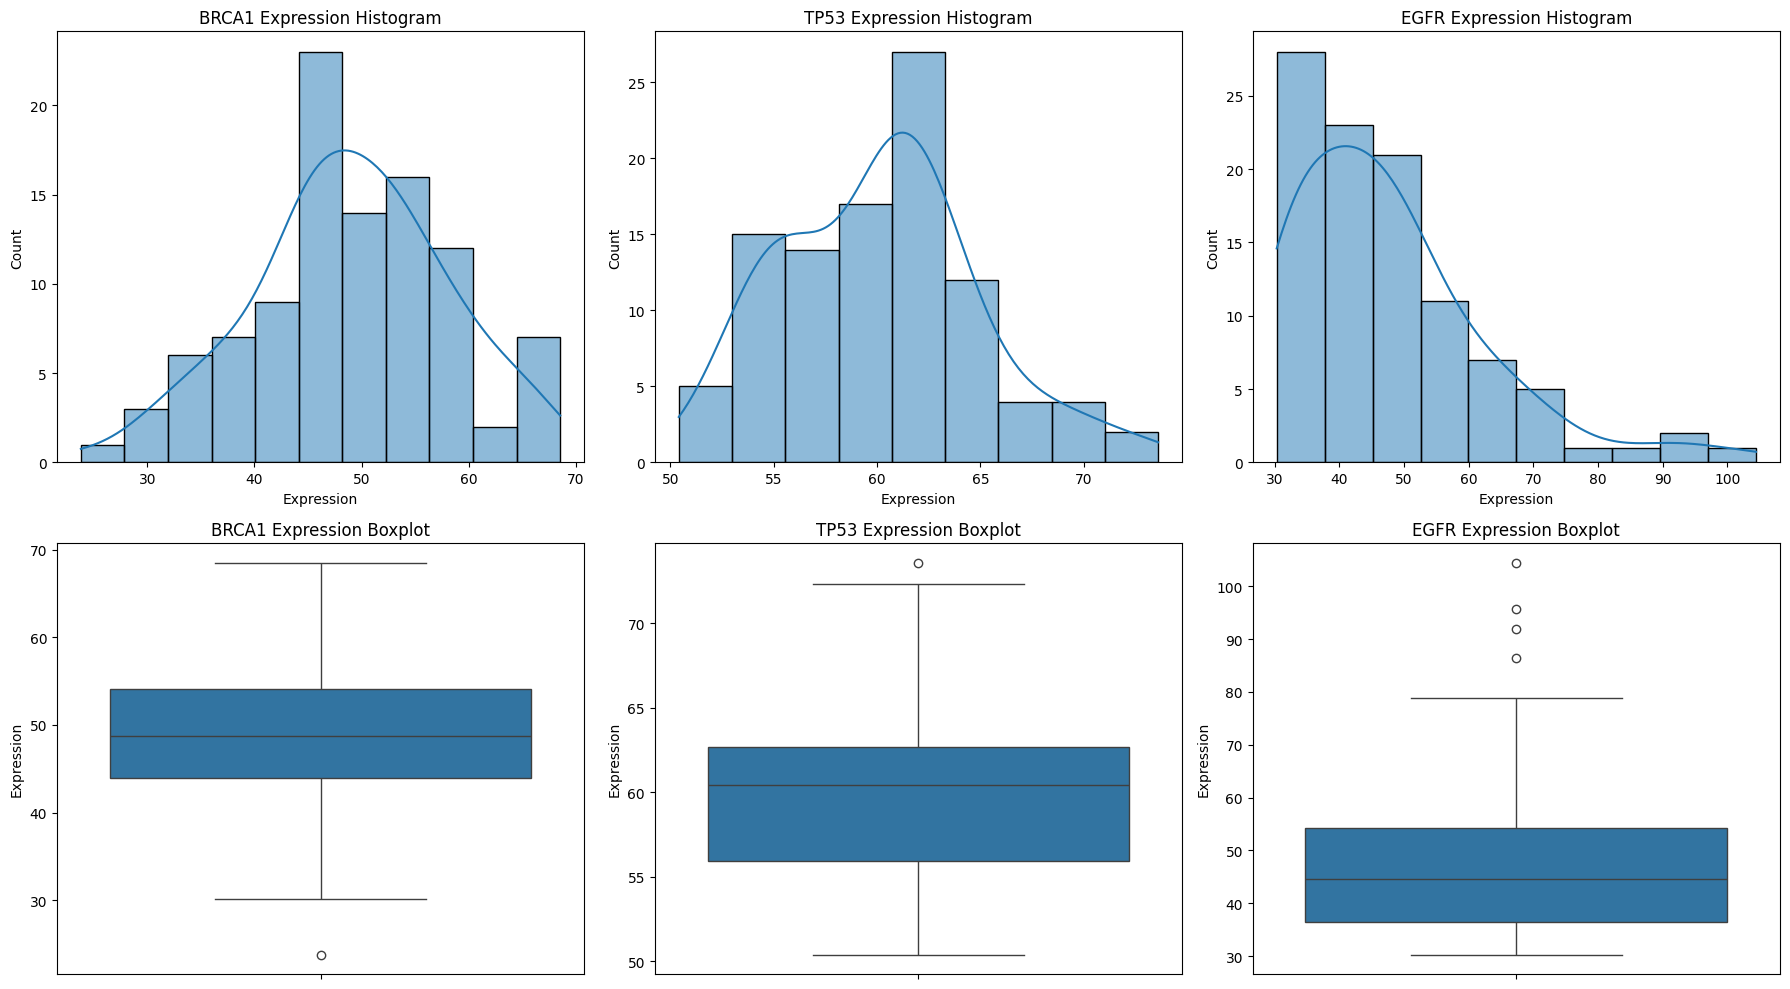

In [ ]:
# Visualizations
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

for idx, gene in enumerate(df['Gene'].unique()):
    data = df[df['Gene'] == gene]['Expression']

    # Histogram with KDE
    sns.histplot(data, kde=True, ax=axs[0, idx])
    axs[0, idx].set_title(f"{gene} Expression Histogram")

    # Boxplot
    sns.boxplot(y=data, ax=axs[1, idx])
    axs[1, idx].set_title(f"{gene} Expression Boxplot")

plt.tight_layout()
plt.show()

In [ ]:
values = [11,12,13,14,25]


mean = sum(values)/len(values)
mean

15.0